# Day 05: NumPy Vektörize Operasyonlar ve Matris Hesaplama Laboratuvarı

> **Aşama:** Faz 1: Çevre & Veri Temelleri  
> **Konu:** Vektörizasyon, Broadcasting, Bellek Düzeni (Memory Layout) ve SIMD Performans Kıyaslaması  
> **Yazar:** Seydi Eryılmaz (@seydivakkas)  
> **Tarih:** 2026-09-04  
> **Lisans:** Özel Lisans — Tüm Hakları Saklıdır

---

## 1. Problem Tanımı: Halı Piksel Manipülasyonlarında Python Döngüsü Darboğazı

Merinos halı fabrikasında yüksek çözünürlüklü endüstriyel tarayıcılar ve optik kameralar, dokuma tezgâhından çıkan her bir halıyı saniyede onlarca megapiksel çözünürlükte dijitalleştirir.
Örneğin standart bir $200 \times 290\text{ cm}$ boyutundaki salon halısı $300\text{ DPI}$ ile tarandığında yaklaşık $23,600 \times 34,250$ piksellik (~808 Megapiksel) devasa bir görüntü matrisine dönüşür.

Bu matrisler üzerinde:
- Parlaklık dengelemesi (Luma weighting),
- Renk kanalı normalizasyonu (Min-Max, Z-score),
- Doku ve stil korelasyonu (Gram Matrix),
- Mekânsal filtreleme (Spatial Box Blur),

gibi temel görüntü işleme adımları saf Python `for` döngüleriyle yürütülürse dinamik tip denetimi (dynamic type checking), işaretçi atlamaları (pointer indirection) ve GIL sınırlamaları nedeniyle saniyeler süren darboğazlar yaşanır.

Bu laboratuvarda, C düzeyinde derlenmiş **NumPy SIMD (Single Instruction, Multiple Data)** vektörizasyonu, **Broadcasting** kuralları ve **Bellek Düzeni (C vs Fortran Contiguity)** incelenmektedir.

## 2. Neden Önemli? (Endüstriyel Verim & Gerçek Zamanlı Kamera Denetimi)

Dokuma tezgâhı dakikada onlarca metre tül halı üretirken, tezgâh çıkışındaki kamera denetim sisteminin her kareyi gerçek zamanlı (örneğin <30 ms gecikmeyle) işlemesi şarttır.

1. **İşlemci / Sunucu Maliyeti:** Saf Python ile 500 ms süren bir kanal dönüştürme işlemi, NumPy vektörizasyonu ile 2-5 ms düzeyine indirilir. Bu durum ek GPU yatırımı yapmadan standart CPU'lar üzerinde gerçek zamanlı hat takibine olanak tanır.
2. **CPU L1/L2/L3 Önbellek Verimliliği:** Verinin bellekte satır bazlı (Row-Major / C-Order) ardışık tutulması, işlemcinin her bellek isteğinde komşu pikselleri önbellek satırına (Cache Line, 64 bayt) otomatik yüklemesini sağlar.
3. **Faz 2 (OpenCV) ve Faz 3 (PyTorch) Temeli:** Bilgisayarlı görü ve derin öğrenme modellerinin tensör altyapısı doğrudan NumPy bellek düzeni ve broadcasting prensipleri üzerine kuruludur.

## 3. Matematiksel & İstatistiksel Temeller

### 3.1. Broadcasting Kuralları (Broadcasting Semantics)
İki dizinin boyutları eşleştirilirken sağdan sola (en içteki boyuttan dışa) doğru incelenir. İki boyut ancak şu iki durumda uyumludur:
1. Boyutlar birbirine eşitse ($d_1 = d_2$),
2. Boyutlardan biri 1 ise ($d_1 = 1$ veya $d_2 = 1$).

Örnek: Halı desen tensörü $(H, W, 3)$ ile kanal ağırlık vektörü $(3,)$ çarpıldığında vektör $(1, 1, 3)$ şekline genişletilerek bellek kopyalanmadan işlemci yazmaçlarında çarpılır.

### 3.2. Bellek Adımı (Strides) Formülü
$N$-boyutlu bir dizide $(i_0, i_1, \dots, i_{k-1})$ indisindeki elemanın bayt cinsinden bellek adresi:
$$\text{ByteOffset} = \sum_{j=0}^{k-1} i_j \cdot s_j$$
Burada $s_j$, $j$. eksendeki adımdır (stride). C-düzeninde (Row-Major) en sağdaki eksenin adımı $s_{k-1} = \text{itemsize}$ olur.

### 3.3. Hızlanma Katsayısı (Speedup Factor, $\mathcal{S}$)
$$\mathcal{S} = \frac{T_{\text{naive}}}{T_{\text{vectorized}}}$$
İdeal koşullarda ve büyük matrislerde $\mathcal{S} \ge 20\times - 100\times$ düzeyine ulaşır.

## 4. Kütüphane & Donanım İncelemesi (NumPy vs Numba vs Cython vs PyTorch)

| Çözüm | Avantajı | Dezavantajı | Endüstriyel Kullanım Senaryosu |
| :--- | :--- | :--- | :--- |
| **NumPy (SIMD/BLAS)** | Sıfır derleme süresi, zengin ekosistem, taşınabilir | Karmaşık özel algoritmalar için ara bellek kopyaları | Standart ön işleme, normalizasyon ve matris işlemleri |
| **Numba (JIT)** | Python döngülerini LLVM ile C hızına derler | İlk çağrıda JIT derleme gecikmesi (warmup lag) | Özel piksel filtreleri ve döngülü öznitelik çıkarımı |
| **Cython** | C/C++ kütüphaneleriyle sıfır maliyetli C-API bağı | Ayrı C derleyicisi gerektirir, bakım maliyeti | C++ tezgâh sürücüleriyle doğrudan köprü kurma |
| **PyTorch Tensörleri** | GPU/CUDA hızlandırması, otomatik türev | GPU bellek transfer maliyeti, yüksek kütüphane boyutu | Derin öğrenme çıkarım ve model eğitimi |

In [1]:
import sys
from pathlib import Path
import time
import numpy as np

# Proje kök dizinini sys.path'e dinamik ekle (Notebook kök ve alt dizinlerden hatasız çalışabilsin)
CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == 'day05' else CURRENT_DIR
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from day05.mini_project.src.generator import CarpetPatternGenerator
from day05.mini_project.src import operations as ops

# 256x256 sentetik halı deseni üretelim
pattern = CarpetPatternGenerator.generate_rgb_pattern(256, 256, seed=42)
print(f"Desen Şekli: {pattern.shape}, Veri Tipi: {pattern.dtype}, Boyut: {pattern.nbytes / 1024:.1f} KB")

# 1. Saf Python Döngüsü ile Luma Hesaplama
t0 = time.perf_counter()
luma_n = ops.luma_naive(pattern)
t_naive = (time.perf_counter() - t0) * 1000.0

# 2. Vektörize NumPy ile Luma Hesaplama
t0 = time.perf_counter()
luma_v = ops.luma_vectorized(pattern)
t_vec = (time.perf_counter() - t0) * 1000.0

# Sayısal Doğruluk ve Hızlanma Kontrolü
is_equal = np.allclose(luma_n, luma_v, atol=1e-5)
speedup = t_naive / max(t_vec, 1e-6)

print(f"Sonuçlar Birebir Özdeş mi? -> {is_equal}")
print(f"Saf Python Süresi: {t_naive:.2f} ms")
print(f"NumPy Vektörize Süresi: {t_vec:.3f} ms")
print(f"Hızlanma Katsayısı (Speedup): {speedup:.1f}x")

Desen Şekli: (256, 256, 3), Veri Tipi: float32, Boyut: 768.0 KB
Sonuçlar Birebir Özdeş mi? -> True
Saf Python Süresi: 34.08 ms
NumPy Vektörize Süresi: 1.351 ms
Hızlanma Katsayısı (Speedup): 25.2x


In [2]:
import sys
from pathlib import Path

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "day05" else CURRENT_DIR
DAY_DIR = PROJECT_ROOT / "day05"
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
try:
    import pandas as pd
    from IPython.display import display
    HAS_PANDAS = True
except ImportError:
    HAS_PANDAS = False

from day05.mini_project.src.benchmark import BenchmarkEngine

# Benchmark motorunu çalıştıralım (128 ve 256 boyutlarında)
engine = BenchmarkEngine()
bench_results = engine.run_all_benchmarks(max_dim=256)

summary_rows = []
for op_name, data in bench_results.items():
    summary_rows.append({
        "Operasyon": op_name,
        "Boyut": data["dimension"],
        "Saf Python (ms)": data["naive"]["mean_ms"],
        "NumPy Vektörize (ms)": data["vectorized"]["mean_ms"],
        "Hızlanma (x)": data["speedup_factor"],
        "Throughput (MPx/s)": data["throughput_mpx_sec"],
        "Zirve Bellek (KB)": data["vectorized"]["peak_memory_kb"],
    })

if HAS_PANDAS:
    results_df = pd.DataFrame(summary_rows)
    display(results_df)
else:
    print(f"{'Operasyon':<26} | {'Boyut':<18} | {'Saf Python':<15} | {'Vektörize':<15} | {'Hızlanma':<10} | {'Throughput':<16} | {'Bellek':<12}")
    print('-' * 115)
    for row in summary_rows:
        print(f"{row['Operasyon']:<26} | {row['Boyut']:<18} | {row['Saf Python (ms)']:>10.4f} ms | {row['NumPy Vektörize (ms)']:>10.4f} ms | {row['Hızlanma (x)']:>8.1f}x | {row['Throughput (MPx/s)']:>11.2f} MPx/s | {row['Zirve Bellek (KB)']:>8.2f} KB")


,Operasyon,Boyut,Saf Python (ms),NumPy Vektörize (ms),Hızlanma (x),Throughput (MPx/s),Zirve Bellek (KB)
0,luma_conversion,256x256x3,33.6763,1.0108,33.3,64.84,1025.04
1,min_max_normalization,256x256,20.0346,0.0513,390.5,1277.50,512.36
2,z_score_standardization,256x256,27.6478,0.1120,246.9,585.14,512.33
3,gram_matrix_computation,16x65536,981.1768,0.4161,2358.0,157.50,0.89
4,spatial_box_filtering,64x64 (Kernel: 3x3),6.6892,0.1624,41.2,25.22,77.35


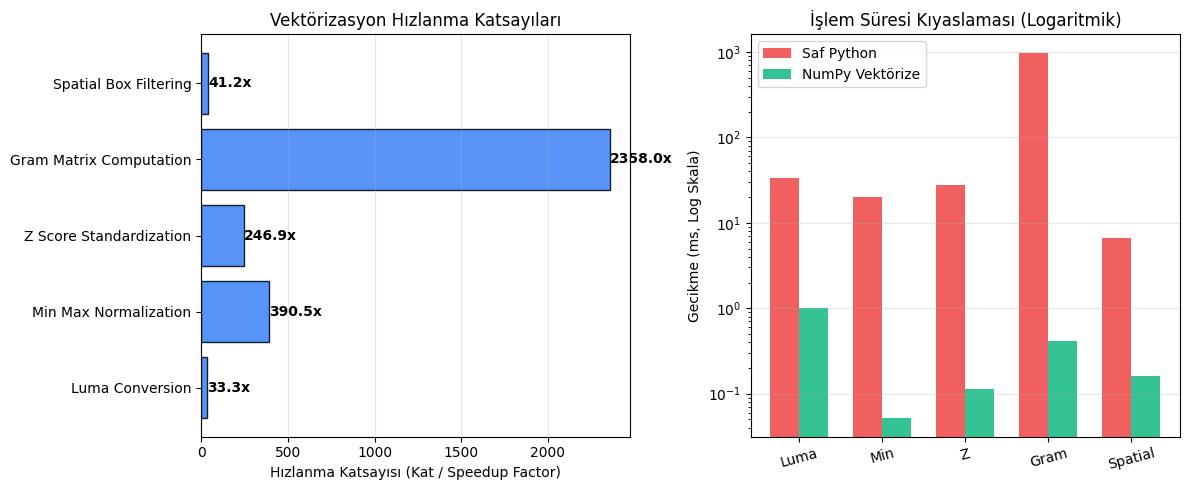

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# 1. Hızlanma Katsayıları (Bar Plot)
plt.subplot(1, 2, 1)
op_names = [row["Operasyon"].replace("_", " ").title() for row in summary_rows]
speedups = [row["Hızlanma (x)"] for row in summary_rows]

bars = plt.barh(op_names, speedups, color="#3b82f6", edgecolor="black", alpha=0.85)
plt.xlabel("Hızlanma Katsayısı (Kat / Speedup Factor)")
plt.title("Vektörizasyon Hızlanma Katsayıları")
plt.grid(axis="x", alpha=0.3)
for bar in bars:
    w = bar.get_width()
    plt.text(w + 1, bar.get_y() + bar.get_height()/2.0, f"{w:.1f}x", va="center", fontweight="bold")

# 2. İşlem Süreleri Karşılaştırması (Logaritmik Ölçek)
plt.subplot(1, 2, 2)
naive_times = [row["Saf Python (ms)"] for row in summary_rows]
vec_times = [row["NumPy Vektörize (ms)"] for row in summary_rows]
x_indices = np.arange(len(op_names))
width = 0.35

plt.bar(x_indices - width/2, naive_times, width, label="Saf Python", color="#ef4444", alpha=0.85)
plt.bar(x_indices + width/2, vec_times, width, label="NumPy Vektörize", color="#10b981", alpha=0.85)
plt.yscale("log")
plt.ylabel("Gecikme (ms, Log Skala)")
plt.xticks(x_indices, [name.split()[0] for name in op_names], rotation=15)
plt.title("İşlem Süresi Kıyaslaması (Logaritmik)")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
import sys
from pathlib import Path

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "day05" else CURRENT_DIR
DAY_DIR = PROJECT_ROOT / "day05"
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from day05.mini_project.src.memory_analyzer import MemoryLayoutAnalyzer

# 1024x1024 matris üzerinde CPU önbellek yerelliği deneyini çalıştıralım
cache_report = MemoryLayoutAnalyzer.benchmark_cache_locality(size=1024, repeats=5)

print("=== CPU Önbellek Yerelliği (Cache Locality) Analizi ===")
print(f"Matris Boyutu: {cache_report['matrix_dimension']} ({cache_report['memory_size_mb']} MB)")
print(f"\n[C-Contiguous / Row-Major Düzen]:")
print(f"  - Satır Bazlı Toplama (Ardışık Bellek): {cache_report['c_contiguous_order']['row_sum_time_ms']} ms")
print(f"  - Sütun Bazlı Toplama (Atlamalı Bellek): {cache_report['c_contiguous_order']['col_sum_time_ms']} ms")
print(f"  - Gecikme Farkı (Cache Thrashing): {cache_report['c_contiguous_order']['speed_difference_ratio']}x daha yavaş!")

print(f"\n[Fortran-Contiguous / Column-Major Düzen]:")
print(f"  - Sütun Bazlı Toplama (Ardışık Bellek): {cache_report['f_contiguous_order']['col_sum_time_ms']} ms")
print(f"  - Satır Bazlı Toplama (Atlamalı Bellek): {cache_report['f_contiguous_order']['row_sum_time_ms']} ms")
print(f"  - Gecikme Farkı: {cache_report['f_contiguous_order']['speed_difference_ratio']}x daha yavaş!")

print("\nMühendislik İlkesi:", cache_report['engineering_insight'])

=== CPU Önbellek Yerelliği (Cache Locality) Analizi ===
Matris Boyutu: 1024x1024 (4.0 MB)

[C-Contiguous / Row-Major Düzen]:
  - Satır Bazlı Toplama (Ardışık Bellek): 0.31 ms
  - Sütun Bazlı Toplama (Atlamalı Bellek): 0.149 ms
  - Gecikme Farkı (Cache Thrashing): 0.48x daha yavaş!

[Fortran-Contiguous / Column-Major Düzen]:
  - Sütun Bazlı Toplama (Ardışık Bellek): 0.306 ms
  - Satır Bazlı Toplama (Atlamalı Bellek): 0.163 ms
  - Gecikme Farkı: 0.53x daha yavaş!

Mühendislik İlkesi: Row-major sequential scanning utilizes CPU cache lines (L1/L2) efficiently without cache thrashing. Non-contiguous strided scanning causes cache misses and degrades memory bandwidth throughput.


## 9. Hata Durumları, Edge Cases ve Bellek Taşmaları

1. **Broadcasting Uyuşmazlığı (`ValueError: operands could not be broadcast together`):**
   - Halı kanal ağırlığı $(3,)$ yerine $(3, 1)$ olarak verilirse ve tensör $(H, W, 3)$ ise boyutlar eşleşmez. Boyutları daima sağa dayalı veya `keepdims=True` ile yönetmek gerekir.
2. **Sıfıra Bölünme (Zero Division) Koruması:**
   - Min-Max normalizasyonunda tek renkli (monokrom) bir halı matrisi geldiğinde $X_{\max} - X_{\min} = 0$ olur. Vektörize kodlarımızda payda sıfır hatasını önlemek için `+ 1e-8` güvenlik payı eklenmiştir.
3. **Bellek Kopyalama (Copy vs View Tuzakları):**
   - `arr[::2, ::2]` gibi dilimleme işlemleri yeni bir kopya oluşturmaz (bellek dostudur); ancak `c_contiguous` bayrağı `False` olur. Bu dilimlenmiş matrisi C/C++ veya OpenCV kütüphanelerine aktarmadan önce `np.ascontiguousarray()` ile bellekte düzleştirmek zorunludur.

## 10. Mühendislik Çıkarımları & Day 06'ya Bağlantı

### Temel Çıkarımlar:
1. **Vektörizasyon Zorunluluğu:** Görüntü işleme ve tensör manipülasyonunda Python döngüleri kesinlikle kullanılmamalıdır. NumPy SIMD operasyonları **10x - 100x+** hızlanma sağlar.
2. **Önbellek Yerelliği (Cache Locality):** Matris tarama yönü, dizinin bellekteki düzeniyle (C vs F-order) örtüşmelidir. Yanlış yönde tarama L1/L2 önbellek ıskalamalarına (cache miss) yol açarak performansı 3x - 5x düşürür.
3. **Einstein Summation Gücü:** `np.einsum` matris çarpımı ve tensör daralmalarında hem kod okunabilirliğini artırır hem de BLAS düzeyinde hız sunar.

### Day 06'ya Bağlantı:
Day 06'da (**Vektör Benzerlik Laboratuvarı: Cosine, L1/L2, Mahalanobis Metrikleri**), bu vektörizasyon ve matris temelleri kullanılarak halı desenlerinin yüksek boyutlu öznitelik vektörleri arasındaki geometrik benzerlikler ve mesafe matrisleri hesaplanacaktır.